Buscando de forma recursiva en: E:/Uni/TFG/dataset/metadata_dev
Total de archivos '.csv' procesados con éxito: 168

--- Balance Total del Dataset (Sumando todas las subcarpetas) ---
 class  num_events_or_frames  num_files  percentage
     0                 71482         97   21.193855
     1                 89489        144   26.532791
     2                  1554         28    0.460749
     3                  2428         33    0.719883
     4                  9404        114    2.788213
     5                 44887         46   13.308645
     6                  7948         75    2.356520
     7                  1611         45    0.477649
     8                 71361         54   21.157980
     9                 30770         19    9.123065
    10                  3534         21    1.047803
    11                  2645         12    0.784222
    12                   164         19    0.048625

Generando gráfico de distribución...
Gráfico guardado automáticamente en tu PC como: 'dis

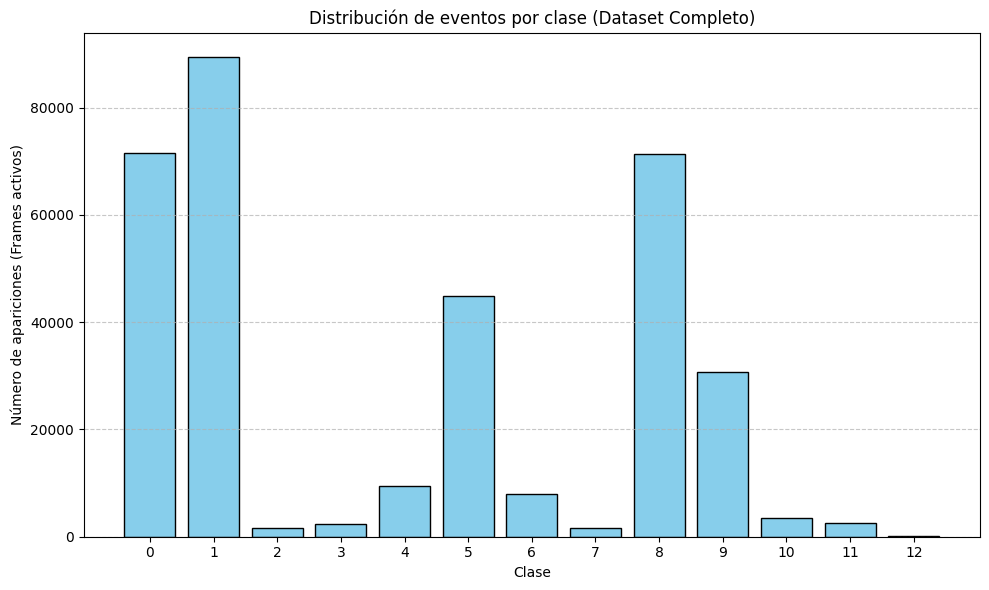

In [2]:
import os
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

# =====================================================================
# CONFIGURACIÓN LOCAL
# =====================================================================
metadata_dir = "E:/Uni/TFG/dataset/metadata_dev"

# =====================================================================
# 1. PROCESAMIENTO RECURSIVO DE METADATOS
# =====================================================================
print("Buscando de forma recursiva en:", metadata_dir)

if not os.path.exists(metadata_dir):
    raise FileNotFoundError(f"¡Ojo! La ruta especificada no existe: {metadata_dir}")

class_counter = Counter()
file_counter = defaultdict(set)
total_csv_procesados = 0

# os.walk busca en la raíz y en CUALQUIER subcarpeta que haya dentro
for root, dirs, files in os.walk(metadata_dir):
    for fname in files:
        if fname.endswith(".csv"):
            total_csv_procesados += 1
            path = os.path.join(root, fname)
            
            try:
                df = pd.read_csv(path, header=None)
                
                if df.empty:
                    continue
                
                # En el formato DCASE: [frame, class, track, x, y, z, distance]
                class_col = df.iloc[:, 1]

                for cls in class_col:
                    class_counter[int(cls)] += 1
                    file_counter[int(cls)].add(fname)
                    
            except Exception as e:
                print(f"⚠️ Error leyendo el archivo {fname}: {e}")

print(f"Total de archivos '.csv' procesados con éxito: {total_csv_procesados}")

# Comprobamos si logramos contar algún evento
if not class_counter:
    print("\n❌ ¡ERROR CRÍTICO! Se han escaneado las subcarpetas pero no se ha podido extraer ninguna clase.")
    print("Comprueba que los archivos dentro de las carpetas tengan datos válidos.")
    exit()

rows = []
for cls in sorted(class_counter.keys()):
    rows.append({
        "class": cls,
        "num_events_or_frames": class_counter[cls],
        "num_files": len(file_counter[cls])
    })

balance_df = pd.DataFrame(rows)
balance_df["percentage"] = 100 * balance_df["num_events_or_frames"] / balance_df["num_events_or_frames"].sum()

# Mostramos la tabla por consola
print("\n--- Balance Total del Dataset (Sumando todas las subcarpetas) ---")
print(balance_df.to_string(index=False))

# =====================================================================
# 2. VISUALIZACIÓN Y GUARDADO DE GRÁFICO
# =====================================================================
print("\nGenerando gráfico de distribución...")
plt.figure(figsize=(10, 6))

# Dibujar las barras usando matplotlib directamente sobre el DataFrame de forma limpia
plt.bar(balance_df["class"].astype(str), balance_df["num_events_or_frames"], color="skyblue", edgecolor="black")

plt.title("Distribución de eventos por clase (Dataset Completo)")
plt.xlabel("Clase")
plt.ylabel("Número de apariciones (Frames activos)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

output_image = "distribucion_clases_tfg.png"
plt.savefig(output_image, dpi=300)
print(f"Gráfico guardado automáticamente en tu PC como: '{output_image}'")

plt.show()

Extrayendo distancias de los metadatos...

--- DIAGNÓSTICO DE FORMATO ---
Archivo analizado: fold4_room23_mix001.csv
Número total de columnas en tu CSV: 6
Contenido de la primera fila completa:
{0: 1, 1: 8, 2: 0, 3: 14, 4: 0, 5: 392}
-------------------------------

Total de frames con distancia válida analizados: 337277


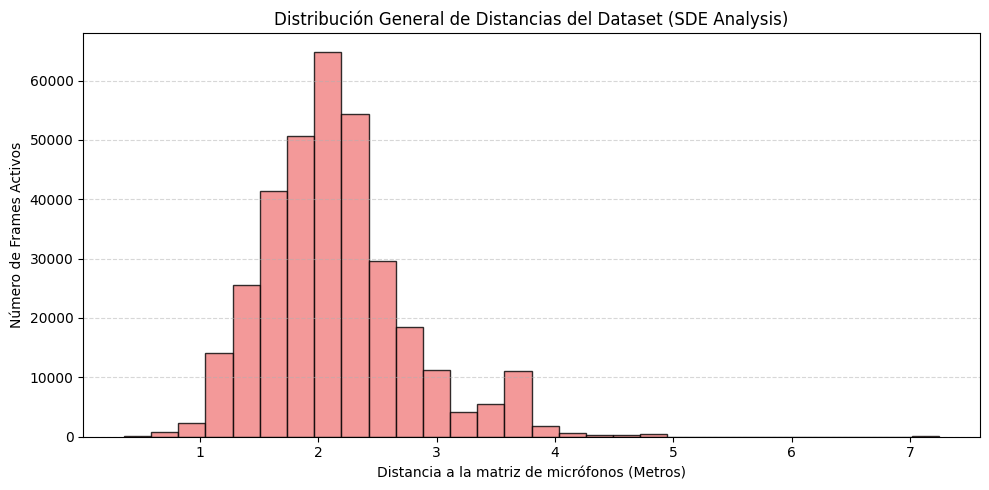

In [5]:
# Celda 1: Análisis de Distancias (Corregido a Metros)
import os
import pandas as pd
import matplotlib.pyplot as plt

metadata_dir = "E:/Uni/TFG/dataset/metadata_dev"
distances = []
diagnostico_hecho = False

print("Extrayendo distancias de los metadatos...")
for root, dirs, files in os.walk(metadata_dir):
    for fname in files:
        if fname.endswith(".csv"):
            try:
                path_completo = os.path.join(root, fname)
                df = pd.read_csv(path_completo, header=None)
                
                if df.empty:
                    continue
                
                # --- CHIVATO DE DIAGNÓSTICO ---
                if not diagnostico_hecho:
                    print("\n--- DIAGNÓSTICO DE FORMATO ---")
                    print(f"Archivo analizado: {fname}")
                    print(f"Número total de columnas en tu CSV: {df.shape[1]}")
                    print("Contenido de la primera fila completa:")
                    print(df.iloc[0].to_dict())
                    print("-------------------------------\n")
                    diagnostico_hecho = True
                
                # Formato DCASE2024 original (Distancia explícita en metros en la columna 7)
                if df.shape[1] >= 7:
                    dist_col = df.iloc[:, 6].dropna()
                    distances.extend(dist_col.tolist())
                
                # Formato local de 6 columnas (Posición en centímetros -> Calculamos norma y pasamos a metros)
                elif df.shape[1] == 6:
                    x = df.iloc[:, 3]
                    y = df.iloc[:, 4]
                    z = df.iloc[:, 5]
                    # Pitágoras tridimensional en cm y dividimos por 100 para pasarlo a metros
                    dist_calculada = ((x**2 + y**2 + z**2).pow(0.5) / 100.0).dropna()
                    distances.extend(dist_calculada.tolist())
                    
            except Exception as e:
                pass

print(f"Total de frames con distancia válida analizados: {len(distances)}")

if len(distances) == 0:
    print("\n❌ Error: No se pudieron extraer distancias.")
else:
    # Graficar el Histograma de Distancias en Metros
    plt.figure(figsize=(10, 5))
    plt.hist(distances, bins=30, color="lightcoral", edgecolor="black", alpha=0.8)
    plt.title("Distribución General de Distancias del Dataset (SDE Analysis)")
    plt.xlabel("Distancia a la matriz de micrófonos (Metros)")
    plt.ylabel("Número de Frames Activos")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    plt.savefig("analisis_preliminar_distancias.png", dpi=300)
    plt.show()

Calculando coordenadas espaciales y ángulos...


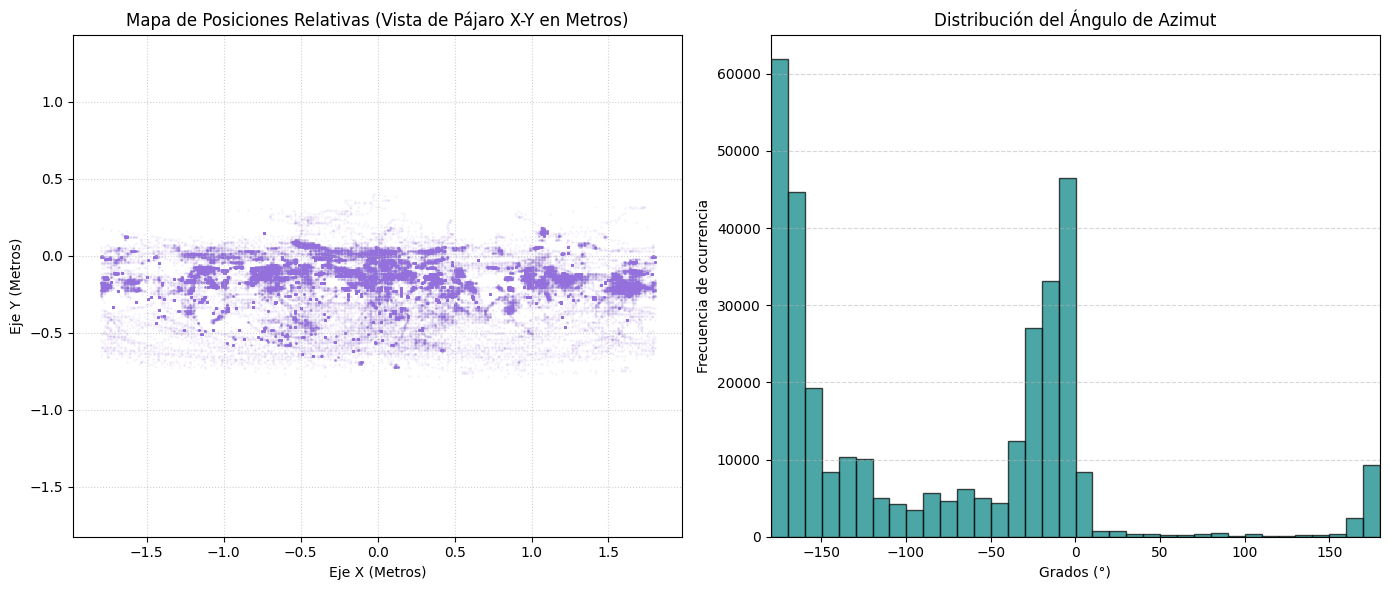

In [6]:
# Celda 2: Análisis Espacial DOA (En metros reales)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metadata_dir = "E:/Uni/TFG/dataset/metadata_dev"
x_coords, y_coords, azimuths = [], [], []

print("Calculando coordenadas espaciales y ángulos...")
for root, dirs, files in os.walk(metadata_dir):
    for fname in files:
        if fname.endswith(".csv"):
            try:
                df = pd.read_csv(os.path.join(root, fname), header=None)
                if not df.empty and df.shape[1] == 6:
                    # Dividimos por 100 para convertir los centímetros a metros reales
                    x_vals = (df.iloc[:, 3] / 100.0).dropna().tolist()
                    y_vals = (df.iloc[:, 4] / 100.0).dropna().tolist()
                    
                    x_coords.extend(x_vals)
                    y_coords.extend(y_vals)
                    
                    for x, y in zip(x_vals, y_vals):
                        az = np.degrees(np.arctan2(y, x))
                        azimuths.append(az)
            except Exception as e:
                pass

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Vista de pájaro de la sala
ax1.scatter(x_coords, y_coords, alpha=0.05, color="mediumpurple", s=1)
ax1.set_title("Mapa de Posiciones Relativas (Vista de Pájaro X-Y en Metros)")
ax1.set_xlabel("Eje X (Metros)")
ax1.set_ylabel("Eje Y (Metros)")
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.axis('equal')

# 2. Histograma del Azimut
ax2.hist(azimuths, bins=36, color="teal", edgecolor="black", alpha=0.7)
ax2.set_title("Distribución del Ángulo de Azimut")
ax2.set_xlabel("Grados (°)")
ax2.set_ylabel("Frecuencia de ocurrencia")
ax2.set_xlim(-180, 180)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("analisis_preliminar_espacial_doa.png", dpi=300)
plt.show()

Calculando solapamiento de eventos por frame...

--- Estadísticas de Polifonía ---
 Fuentes_Simultaneas  Num_Frames  Porcentaje
                   1      140274   62.274529
                   2       62536   27.762807
                   3       18257    8.105180
                   4        3764    1.671025
                   5         416    0.184683
                   6           4    0.001776


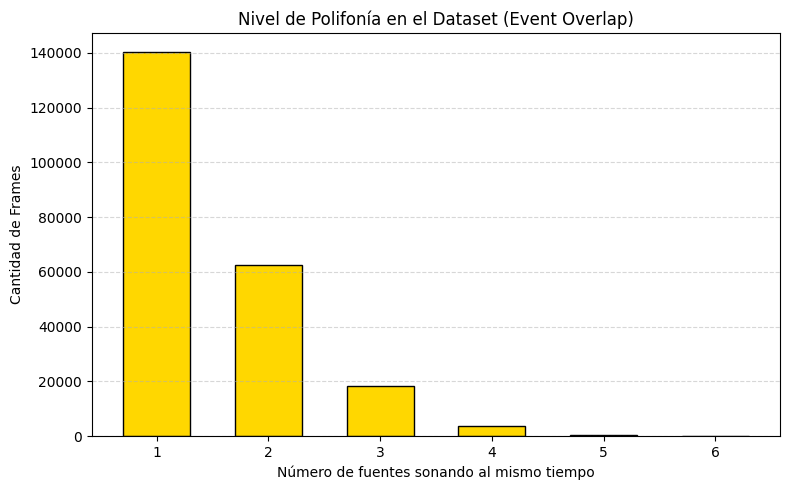

In [7]:
# Celda 3: Análisis de Polifonía
import os
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

metadata_dir = "E:/Uni/TFG/dataset/metadata_dev"
polyphony_per_frame = []

print("Calculando solapamiento de eventos por frame...")
for root, dirs, files in os.walk(metadata_dir):
    for fname in files:
        if fname.endswith(".csv"):
            try:
                df = pd.read_csv(os.path.join(root, fname), header=None)
                if not df.empty:
                    # Agrupamos por el ID del Frame (columna 0) y contamos fuentes simultáneas
                    counts = df.groupby(0).size().tolist()
                    polyphony_per_frame.extend(counts)
            except Exception as e:
                pass

poly_counts = Counter(polyphony_per_frame)
poly_df = pd.DataFrame([{"Fuentes_Simultaneas": k, "Num_Frames": v} for k, v in poly_counts.items()])
poly_df = poly_df.sort_values(by="Fuentes_Simultaneas")
poly_df["Porcentaje"] = 100 * poly_df["Num_Frames"] / poly_df["Num_Frames"].sum()

print("\n--- Estadísticas de Polifonía ---")
print(poly_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(poly_df["Fuentes_Simultaneas"].astype(str), poly_df["Num_Frames"], color="gold", edgecolor="black", width=0.6)
plt.title("Nivel de Polifonía en el Dataset (Event Overlap)")
plt.xlabel("Número de fuentes sonando al mismo tiempo")
plt.ylabel("Cantidad de Frames")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("analisis_preliminar_polifonia.png", dpi=300)
plt.show()